### How standard MHA does it (The Stupid Way):
1. It takes all 1,000 past words + the new 1,001st word.
2. It passes ALL 1,001 words through the Blender ($W_q$, $W_k$, $W_v$) to calculate 1,001 Queries, 1,001 Keys, and 1,001 Values.
3. It does the massive matrix multiplication.
4. It throws the answer out, outputs Word 1,001, and completely forgets everything it just did.
5. When it needs to predict Word 1,002, it runs the entire Blender again for words 1 through 1,001.
6. It recalculates the exact same numbers for the exact same past words, over and over. This makes the model exponentially slower with every new word it types.

### 2. The Insight: What actually changes?
Let's look closely at the Attention formula:
$$\text{Attention}(Q, K, V) = \text{Softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

When we are predicting Word 1,001, what do we actually need?
* We need Word 1,001's Query ($Q$). It is the only token actively asking, "What should I look at?"
* It needs to compare its $Q$ against the Keys ($K$) of words 1 through 1,000.
* It needs to retrieve the Values ($V$) of words 1 through 1,000.

**The Golden Rule:** Once a word has been generated and its $K$ and $V$ are calculated by the Blender, those numbers never, ever change. The "Label" ($K$) and "Meaning" ($V$) of Word 12 are exactly the same on step 1,000 as they were on step 13.
The only thing that changes is the current token's $Q$.

---

### 3. The Solution: The KV Cache
Instead of throwing our math away, we create a notebook in the GPU's memory (VRAM). We call this the **KV Cache**.

**How the Cache works step-by-step:**
1. **Word 1 is generated:** We calculate its $K$ and $V$. We save them in the Cache.
2. **Word 2 arrives:** We DO NOT recalculate Word 1.
   * We only calculate Word 2's $Q$, $K$, and $V$.
   * We append Word 2's $K$ and $V$ to the Cache.
   * Word 2's $Q$ looks at the Cache to get its attention scores.
3. **Word 1,001 arrives:**
   * The model only passes Word 1,001 through the Blender to get a single $Q$, $K$, $V$.
   * It appends the new $K$ and $V$ to a Cache that already has 1,000 entries sitting perfectly ready.
   * Word 1,001's single $Q$ does a simple dot product against the 1,000 cached Keys.

**The Result:** We completely eliminated the redundant math. The speed of generating token 1,001 becomes almost as fast as generating token 2.

---

### 4. The Catch (The New Crisis)
You just solved the speed problem! But you introduced a terrifying new problem: Memory.

Those $K$ and $V$ matrices are huge.
Let's do some quick back-of-the-napkin math for a model like Llama 3 (8B):
* It has 32 layers of Attention.
* It has 32 Heads per layer.
* Head dimension is 128.
* It stores $K$ and $V$ using 16-bit precision (2 bytes per number).

If you want the model to remember 8,000 tokens of context, the KV Cache for a single user takes up roughly **4 Gigabytes** of GPU RAM.
If you are OpenAI and you have 10,000 users chatting with ChatGPT at the exact same time... you need **40,000 Gigabytes** of VRAM just to store the notebook. The Cache becomes larger than the model itself.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import math

class AttentionWithCache(nn.Module):
    def __init__(self, d_model=256, num_heads=8):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        
        self.w_q = nn.Linear(d_model, d_model, bias=False)
        self.w_k = nn.Linear(d_model, d_model, bias=False)
        self.w_v = nn.Linear(d_model, d_model, bias=False)
        self.w_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, kv_cache=None):
        B, T, C = x.shape
        
        # 1. Project to Q, K, V
        q = self.w_q(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.w_k(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.w_v(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        
        # 2. THE CACHE LOGIC
        if kv_cache is not None:
            # We are generating! x is just the ONE newest token (T=1).
            # We grab the past Keys and Values from the cache
            past_k, past_v = kv_cache
            
            # Append the new token's K and V to the past notebook
            # dim=2 is the 'Sequence Length' dimension
            k = torch.cat([past_k, k], dim=2) 
            v = torch.cat([past_v, v], dim=2)
            
            # Update the notebook for the next word
            kv_cache = (k, v)
            
            # Because we only have 1 Query (T=1) looking at Past+1 Keys, 
            # we don't even need a Causal Mask here! The future doesn't exist yet.
            scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        else:
            # Standard Training Mode (Processing whole sequence at once)
            scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
            mask = torch.tril(torch.ones(T, T)).to(x.device)
            scores = scores.masked_fill(mask == 0, float('-inf'))
            
        # 3. Attention Math
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, v)
        
        # 4. Reassemble
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.w_o(out)
        
        return out, kv_cache

# --- THE BENCHMARK LAB ---
def run_benchmark():
    print("--- KV Cache Speed Benchmark ---")
    
    d_model = 256
    seq_len = 10        # Start with a prompt of 10 tokens
    gen_tokens = 200    # Generate 200 new tokens
    
    model = AttentionWithCache(d_model=d_model)
    
    # Fake embedding matrix to simulate getting new words
    embedding = nn.Embedding(1000, d_model) 
    
    # ---------------------------------------------------------
    # TEST 1: WITHOUT CACHE (The O(N^2) Amnesia Way)
    # ---------------------------------------------------------
    print("\n1. Generating WITHOUT Cache (Recomputing everything)...")
    # Start with a prompt of 10 tokens
    current_sequence_ids = torch.randint(0, 1000, (1, seq_len)) 
    
    start_time = time.perf_counter()
    for _ in range(gen_tokens):
        # 1. Embed the ENTIRE sequence (from word 1 to current word)
        x = embedding(current_sequence_ids) 
        
        # 2. Pass ENTIRE sequence through Attention
        out, _ = model(x, kv_cache=None)
        
        # 3. Grab the last token, pretend it's the new word, and append it
        next_token_id = torch.randint(0, 1000, (1, 1))
        current_sequence_ids = torch.cat([current_sequence_ids, next_token_id], dim=1)
        
    time_no_cache = time.perf_counter() - start_time
    print(f"   Time taken: {time_no_cache:.4f} seconds")


    # ---------------------------------------------------------
    # TEST 2: WITH CACHE (The Smart Way)
    # ---------------------------------------------------------
    print("\n2. Generating WITH Cache (Appending memory)...")
    current_sequence_ids = torch.randint(0, 1000, (1, seq_len))
    
    start_time = time.perf_counter()
    
    # Step A: "Prefill" phase - Process the initial prompt to build the first cache
    x = embedding(current_sequence_ids)
    out, kv_cache = model(x, kv_cache=None) 
    
    # Step B: "Decoding" phase - Generate one token at a time
    newest_token_id = torch.randint(0, 1000, (1, 1))
    
    for _ in range(gen_tokens):
        # 1. ONLY embed the ONE newest token
        x_new = embedding(newest_token_id) 
        
        # 2. Pass ONLY the new token into Attention, but give it the cache!
        out, kv_cache = model(x_new, kv_cache=kv_cache)
        
        # 3. Pretend we picked a new word for the next loop
        newest_token_id = torch.randint(0, 1000, (1, 1))
        
    time_with_cache = time.perf_counter() - start_time
    print(f"   Time taken: {time_with_cache:.4f} seconds")
    
    # --- Results ---
    speedup = time_no_cache / time_with_cache
    print(f"\n🚀 RESULTS: KV Cache was {speedup:.1f}x faster!")

if __name__ == "__main__":
    run_benchmark()

--- KV Cache Speed Benchmark ---

1. Generating WITHOUT Cache (Recomputing everything)...
   Time taken: 0.7049 seconds

2. Generating WITH Cache (Appending memory)...
   Time taken: 0.0752 seconds

🚀 RESULTS: KV Cache was 9.4x faster!


Plot saved successfully.


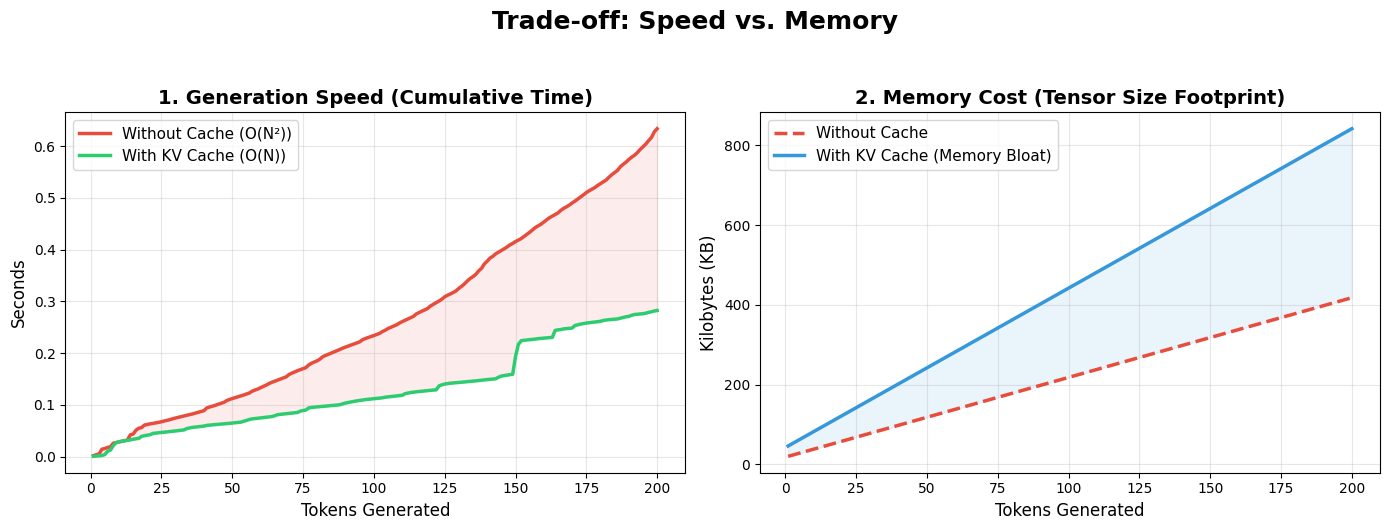

In [3]:
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt

class AttentionWithCache(nn.Module):
    def __init__(self, d_model=256, num_heads=8):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        
        self.w_q = nn.Linear(d_model, d_model, bias=False)
        self.w_k = nn.Linear(d_model, d_model, bias=False)
        self.w_v = nn.Linear(d_model, d_model, bias=False)
        self.w_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, kv_cache=None):
        B, T, C = x.shape
        import math
        
        q = self.w_q(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.w_k(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.w_v(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        
        if kv_cache is not None:
            past_k, past_v = kv_cache
            k = torch.cat([past_k, k], dim=2) 
            v = torch.cat([past_v, v], dim=2)
            
            scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        else:
            scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
            mask = torch.tril(torch.ones(T, T)).to(x.device)
            scores = scores.masked_fill(mask == 0, float('-inf'))
            
        kv_cache = (k, v) # Always save it so we can start generating!
            
        import torch.nn.functional as F
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, v)
        
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.w_o(out)
        
        return out, kv_cache

def run_benchmark_and_plot():
    d_model = 512
    seq_len = 10        
    gen_tokens = 200    
    
    model = AttentionWithCache(d_model=d_model)
    embedding = nn.Embedding(2000, d_model) 
    
    # Trackers
    times_no_cache = []
    times_with_cache = []
    
    mem_no_cache = []
    mem_with_cache = []
    
    # --- TEST 1: NO CACHE ---
    current_ids = torch.randint(0, 1000, (1, seq_len)) 
    cumulative_time = 0
    
    for i in range(gen_tokens):
        start = time.perf_counter()
        
        x = embedding(current_ids) 
        out, _ = model(x, kv_cache=None)
        
        next_token = torch.randint(0, 1000, (1, 1))
        current_ids = torch.cat([current_ids, next_token], dim=1)
        
        step_time = time.perf_counter() - start
        cumulative_time += step_time
        times_no_cache.append(cumulative_time)
        
        # Memory tracking
        mem_kb = (x.nelement() * 4) / 1024
        mem_no_cache.append(mem_kb)

    # --- TEST 2: WITH CACHE ---
    current_ids = torch.randint(0, 1000, (1, seq_len))
    cumulative_time = 0
    
    # Prefill
    x = embedding(current_ids)
    out, kv_cache = model(x, kv_cache=None) 
    
    newest_token = torch.randint(0, 1000, (1, 1))
    
    for i in range(gen_tokens):
        start = time.perf_counter()
        
        x_new = embedding(newest_token) 
        out, kv_cache = model(x_new, kv_cache=kv_cache)
        
        newest_token = torch.randint(0, 1000, (1, 1))
        
        step_time = time.perf_counter() - start
        cumulative_time += step_time
        times_with_cache.append(cumulative_time)
        
        k_cache, v_cache = kv_cache
        cache_bytes = (k_cache.nelement() + v_cache.nelement()) * 4
        new_tok_bytes = x_new.nelement() * 4
        mem_kb = (cache_bytes + new_tok_bytes) / 1024 
        mem_with_cache.append(mem_kb)
        
    # --- PLOTTING ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    steps = list(range(1, gen_tokens + 1))
    ax1.plot(steps, times_no_cache, label='Without Cache (O(N²))', color='#e74c3c', linewidth=2.5)
    ax1.plot(steps, times_with_cache, label='With KV Cache (O(N))', color='#2ecc71', linewidth=2.5)
    ax1.set_title("1. Generation Speed (Cumulative Time)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Tokens Generated", fontsize=12)
    ax1.set_ylabel("Seconds", fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.fill_between(steps, times_no_cache, times_with_cache, color='#e74c3c', alpha=0.1)
    
    ax2.plot(steps, mem_no_cache, label='Without Cache', color='#e74c3c', linestyle='--', linewidth=2.5)
    ax2.plot(steps, mem_with_cache, label='With KV Cache (Memory Bloat)', color='#3498db', linewidth=2.5)
    ax2.set_title("2. Memory Cost (Tensor Size Footprint)", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Tokens Generated", fontsize=12)
    ax2.set_ylabel("Kilobytes (KB)", fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.fill_between(steps, mem_no_cache, mem_with_cache, color='#3498db', alpha=0.1)
    
    plt.suptitle("Trade-off: Speed vs. Memory", fontsize=18, y=1.05, fontweight='bold')
    plt.tight_layout()
    plt.savefig("kv_cache_tradeoff.png", dpi=300, bbox_inches='tight')
    print("Plot saved successfully.")

run_benchmark_and_plot()